# modular_charge_spreading

Standalone modular-Hamiltonian charge-propagation diagnostic for the DW ground state and the OW flattened-Hamiltonian surrogate.

Runs:
- exact DW ground state, once;
- flattened projector-sum DW ground state with `nshell=1,2`, `trial_orbitals="X"`, standard construction;
- flattened projector-sum DW ground state with `nshell=1,2`, `trial_orbitals="X"`, and `dw_truncation=True`;
- flattened projector-sum DW ground state with `nshell=1,2`, `trial_orbitals="X"`, `dw_truncation=True`, and `triv_region_local_mode=True`.

Geometry and convention:
- `Nx=20`, `Ny=40`;
- `alpha_1=1` is the topological slab mass;
- `alpha_2=30` is the trivial outside mass;
- build the modular Hamiltonian from the covariance averaged over all half-cylinder cuts `A(y0)=[0,Nx) x [y0,y0+Ny//2)` in a common relative-y basis.

The notebook builds two aggregate injection configurations, places one unit of charge in each local orbital at every selected unit cell, evolves the full total injected charge under the half-system modular Hamiltonian, and saves charge-density heatmap GIFs plus NPZ trajectories.


## Runtime Controls

In [18]:

# CPU / BLAS thread controls.
# Run before any non-stdlib imports in the notebook.
import os
import multiprocessing as mp

CPU_CAP = 14
AFFINITY_START = 97  # Set to None to skip affinity pinning.

cpu_available = mp.cpu_count()
cpu_use = max(1, min(int(CPU_CAP), cpu_available))

os.environ["MY_CPU_COUNT"] = str(cpu_use)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")
for _k in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "NUMEXPR_MAX_THREADS",
):
    os.environ[_k] = str(cpu_use)

if AFFINITY_START is not None:
    try:
        os.sched_setaffinity(0, set(range(int(AFFINITY_START), int(AFFINITY_START) + cpu_use)))
        print(f"CPU affinity set to cores [{AFFINITY_START}, {AFFINITY_START + cpu_use - 1}]")
    except Exception as exc:
        print(f"CPU affinity not set: {exc}")

print(f"CPU_CAP={CPU_CAP}, cpu_available={cpu_available}, cpu_use={cpu_use}")


CPU affinity set to cores [97, 110]
CPU_CAP=14, cpu_available=112, cpu_use=14


## Setup

In [19]:

# Path setup for imports from `src`.
import sys
from pathlib import Path


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "fgtn" / "classA_U1FGTN.py").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from {start}")


ROOT = find_repo_root(Path.cwd())
NOTEBOOK_DIR = ROOT / "notebooks" / "modular_charge_spreading"
OUTPUT_DIR = NOTEBOOK_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"ROOT = {ROOT}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")


ROOT = /home/abhuiyan/class_A_fermionic_adaptive_circuit
OUTPUT_DIR = /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_charge_spreading


## Imports And Configuration

In [20]:

import importlib
import json

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, Markdown, Video, display
import numpy as np
import pandas as pd

classA_U1FGTN_module = importlib.import_module("fgtn.classA_U1FGTN")
importlib.reload(classA_U1FGTN_module)
classA_U1FGTN = classA_U1FGTN_module.classA_U1FGTN

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.dpi"] = 120

NX, NY = 20, 40
ALPHA_1, ALPHA_2 = 1, 30
PERIODIC = True
TRIAL_ORBITAL = "X"
FLATTENED_NSHELLS = [1, 2]
FLATTENED_VARIANTS = [
    {"variant": "standard", "dw_truncation": False, "triv_region_local_mode": False},
    {"variant": "triv_region_local_mode", "dw_truncation": False, "triv_region_local_mode": True},
    {"variant": "dw_truncation", "dw_truncation": True, "triv_region_local_mode": False},
    {"variant": "dw_truncation_and_triv_region_local_mode", "dw_truncation": True, "triv_region_local_mode": True},
]

RNG_SEED = 12345
DT_DEFAULT = 0.05
T_FINAL = 2 * NX
MODULAR_EPS = 1e-10
MODULAR_COVARIANCE_MODE = "yavg_half_window"

VIDEO_FRAME_STRIDE = 10  # full per-step trajectories are saved to NPZ; videos are downsampled for file size.
VIDEO_FPS = 12
DISPLAY_SAVED_VIDEOS = True
DISPLAY_INTERACTIVE_ANIMATIONS = False
INTERACTIVE_FRAME_STRIDE = VIDEO_FRAME_STRIDE
RUN_FULL_SWEEP = True

print(f"Nx={NX}, Ny={NY}, alpha_1={ALPHA_1}, alpha_2={ALPHA_2}, trial_orbital={TRIAL_ORBITAL}")
print(f"T_FINAL={T_FINAL}, DT_DEFAULT={DT_DEFAULT}, nominal steps={int(round(T_FINAL / DT_DEFAULT))}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")


Nx=20, Ny=40, alpha_1=1, alpha_2=30, trial_orbital=X
T_FINAL=40, DT_DEFAULT=0.05, nominal steps=800
OUTPUT_DIR=/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_charge_spreading


## Math Helpers

The reduced covariance uses the repo convention `C=(I+G)/2`. Before extracting the modular Hamiltonian, average the reduced covariance over all translated half-cylinder cuts, mapping each cut to the same relative-y basis. For the modular Hamiltonian,
`G_A = V diag(g) V†` and `h_mod = V diag(-2 arctanh(g)) V†`.

The injected product state is a reduced-space vacuum plus aggregate local charges. Each selected unit cell contributes one unit of charge in orbital `A` and one unit of charge in orbital `B`, so the total injected charge is the sum over all selected unit cells and is evolved without renormalizing back to unit charge. Time evolution is exact in the modular eigenbasis via phase factors `exp(-i h t)`.


In [21]:

def full_top_index(nx, x, y, mu):
    return int(mu) + 2 * int(x) + 2 * int(nx) * int(y)


def half_window_indices(nx, ny, y0=0):
    """Indices for A(y0)=[0,Nx) x [y0,y0+Ny//2) in relative-y, x, orbital order."""
    y_rel_vals = np.arange(ny // 2, dtype=int)
    return np.asarray([
        full_top_index(nx, x, (int(y0) + int(y_rel)) % int(ny), mu)
        for y_rel in y_rel_vals
        for x in range(nx)
        for mu in range(2)
    ], dtype=int)


def lower_half_indices(nx, ny):
    return half_window_indices(nx, ny, y0=0)


def reduced_site_index(nx, x, y, mu):
    # Reduced ordering is relative-y, x, orbital for a half-window of height Ny//2.
    return int(mu) + 2 * int(x) + 2 * int(nx) * int(y)


def reduce_top_covariance_to_y_averaged_half_window(G_top, nx, ny):
    """Average G restricted to A(y0) over all y0 before extracting H_mod."""
    G_top = np.asarray(G_top, dtype=np.complex128)
    G_accum = np.zeros((nx * (ny // 2) * 2, nx * (ny // 2) * 2), dtype=np.complex128)
    for y0 in range(ny):
        idx = half_window_indices(nx, ny, y0=y0)
        G_accum += G_top[np.ix_(idx, idx)]
    G_avg = G_accum / float(ny)
    G_avg = 0.5 * (G_avg + G_avg.conj().T)
    idx_ref = half_window_indices(nx, ny, y0=0)
    return G_avg, idx_ref


def reduce_top_covariance_to_lower_half(G_top, nx, ny):
    # Backward-compatible name: this now returns the y0-averaged half-window covariance.
    return reduce_top_covariance_to_y_averaged_half_window(G_top, nx, ny)


def modular_hamiltonian_from_covariance(G_sub, eps=MODULAR_EPS):
    G_sub = np.asarray(G_sub, dtype=np.complex128)
    G_sub = 0.5 * (G_sub + G_sub.conj().T)
    g_vals, g_vecs = np.linalg.eigh(G_sub)
    g_vals = np.clip(np.real_if_close(g_vals), -1.0 + eps, 1.0 - eps)
    h_vals = -2.0 * np.arctanh(g_vals)
    h_mod = (g_vecs * h_vals[None, :]) @ g_vecs.conj().T
    h_mod = 0.5 * (h_mod + h_mod.conj().T)
    hermiticity_error = float(np.max(np.abs(h_mod - h_mod.conj().T)))
    return {
        "h_mod": h_mod,
        "h_vals": np.asarray(h_vals, dtype=float),
        "h_vecs": g_vecs,
        "g_vals": np.asarray(g_vals, dtype=float),
        "hermiticity_error": hermiticity_error,
    }


def charge_map_from_phi(phi, nx=NX, ny_sub=NY // 2):
    phi = np.asarray(phi, dtype=np.complex128)
    phi_y_x_mu = phi.reshape(ny_sub, nx, 2)
    return np.sum(np.abs(phi_y_x_mu) ** 2, axis=2).T  # (Nx, Ny_sub)


def charge_maps_from_phi_t(phi_t, nx=NX, ny_sub=NY // 2):
    phi_t = np.asarray(phi_t, dtype=np.complex128)
    phi_t_y_x_mu = phi_t.reshape(phi_t.shape[0], ny_sub, nx, 2)
    return np.sum(np.abs(phi_t_y_x_mu) ** 2, axis=3).transpose(0, 2, 1)  # (T, Nx, Ny_sub)


## State Builders

In [22]:
def topological_region_mask(model):
    Nx, Ny = model.Nx, model.Ny
    mask = np.zeros((Nx, Ny), dtype=bool)
    if getattr(model, "DW", False) and hasattr(model, "DW_loc") and isinstance(model.DW_loc, (list, tuple)) and len(model.DW_loc) == 2:
        xL = int(model.DW_loc[0]) % Nx
        xR = int(model.DW_loc[1]) % Nx
        if xL <= xR:
            mask[xL:xR + 1, :] = True
        else:
            mask[xL:, :] = True
            mask[:xR + 1, :] = True
    elif hasattr(model, "alpha_profile"):
        mask = np.isclose(np.real(model.alpha_profile), float(model.alpha_1))
    else:
        mask[:, :] = True
    if not np.any(mask):
        raise ValueError("empty topological-region mask")
    return mask


def apply_triv_region_local_mode_to_flat_hamiltonian(model, H_flat):
    if not getattr(model, "DW", False):
        return H_flat
    topo_mask = topological_region_mask(model)
    Nx, Ny = model.Nx, model.Ny
    Nlayer = 2 * Nx * Ny
    keep = np.zeros(Nlayer, dtype=bool)

    def idx(mu, x, y):
        return mu + 2 * x + 2 * Nx * y

    for x in range(Nx):
        for y in range(Ny):
            if topo_mask[x, y]:
                keep[idx(0, x, y)] = True
                keep[idx(1, x, y)] = True

    H_local = np.array(H_flat, dtype=np.complex128, copy=True)
    H_local[~keep, :] = 0.0
    H_local[:, ~keep] = 0.0
    for x in range(Nx):
        for y in range(Ny):
            if not topo_mask[x, y]:
                H_local[idx(0, x, y), idx(0, x, y)] = -1.0
                H_local[idx(1, x, y), idx(1, x, y)] = -1.0
    return 0.5 * (H_local + H_local.conj().T)


def build_flattened_sigma_x_covariance(model, *, dw_truncation=False, triv_region_local_mode=False):
    Nlayer = 2 * model.Nx * model.Ny
    model.construct_OW_projectors(
        nshell=model.nshell,
        DW=model.DW,
        trial_orbitals=TRIAL_ORBITAL,
        dw_truncation=dw_truncation,
    )
    WA_p = model.WF_Ap.reshape(Nlayer, -1)
    WB_p = model.WF_Bp.reshape(Nlayer, -1)
    WA_m = model.WF_Am.reshape(Nlayer, -1)
    WB_m = model.WF_Bm.reshape(Nlayer, -1)

    H_flat = WA_p @ WA_p.conj().T + WB_p @ WB_p.conj().T - WA_m @ WA_m.conj().T - WB_m @ WB_m.conj().T
    H_flat = 0.5 * (H_flat + H_flat.conj().T)
    if triv_region_local_mode:
        H_flat = apply_triv_region_local_mode_to_flat_hamiltonian(model, H_flat)

    evals, evecs = np.linalg.eigh(H_flat)
    occ_mask = evals < 0.0
    if not np.any(occ_mask):
        occ_mask = np.zeros_like(evals, dtype=bool)
        occ_mask[np.argsort(evals)[: Nlayer // 2]] = True
    U_occ = evecs[:, occ_mask]
    P_occ = U_occ @ U_occ.conj().T
    G_flat = 2.0 * P_occ.conj() - np.eye(Nlayer, dtype=np.complex128)
    return H_flat, G_flat, evals


def _flattened_run_label(nshell, variant_spec):
    label = f"flattened_sigma_x_nshell_{int(nshell)}"
    variant = str(variant_spec["variant"])
    if variant != "standard":
        label += f"_{variant}"
    return label


def build_run_inputs():
    runs = []

    exact_model = classA_U1FGTN(NX, NY, nshell=None, DW=True, alpha_1=ALPHA_1, alpha_2=ALPHA_2)
    exact_H = exact_model._domain_wall_hamiltonian(periodic=PERIODIC)
    exact_G = exact_model.G_CI_domain_wall(periodic=PERIODIC)
    runs.append({
        "run_label": "exact_dw_gs",
        "state_type": "exact",
        "configuration_label": "exact",
        "dw_truncation": False,
        "triv_region_local_mode": False,
        "nshell": None,
        "model": exact_model,
        "H": exact_H,
        "G_top": exact_G,
        "spectrum": np.linalg.eigvalsh(exact_H),
    })

    for variant_spec in FLATTENED_VARIANTS:
        for nshell in FLATTENED_NSHELLS:
            model = classA_U1FGTN(NX, NY, nshell=int(nshell), DW=True, alpha_1=ALPHA_1, alpha_2=ALPHA_2)
            H_flat, G_flat, evals_flat = build_flattened_sigma_x_covariance(
                model,
                dw_truncation=bool(variant_spec["dw_truncation"]),
                triv_region_local_mode=bool(variant_spec["triv_region_local_mode"]),
            )
            runs.append({
                "run_label": _flattened_run_label(nshell, variant_spec),
                "state_type": "flattened_sigma_x",
                "configuration_label": str(variant_spec["variant"]),
                "dw_truncation": bool(variant_spec["dw_truncation"]),
                "triv_region_local_mode": bool(variant_spec["triv_region_local_mode"]),
                "nshell": int(nshell),
                "model": model,
                "H": H_flat,
                "G_top": G_flat,
                "spectrum": evals_flat,
            })

    dw_loc = list(getattr(exact_model, "DW_loc", []))
    if len(dw_loc) != 2:
        raise ValueError(f"Expected two DW locations, got {dw_loc}")
    return runs, dw_loc


def prepare_modular_data(run):
    G_A, idx_A = reduce_top_covariance_to_lower_half(run["G_top"], NX, NY)
    expected_dim = NX * (NY // 2) * 2
    if G_A.shape != (expected_dim, expected_dim):
        raise ValueError(f"Reduced dimension mismatch: expected {(expected_dim, expected_dim)}, got {G_A.shape}")
    mod = modular_hamiltonian_from_covariance(G_A)
    run_mod = dict(run)
    run_mod.update({
        "G_A": G_A,
        "idx_A": idx_A,
        "h_mod": mod["h_mod"],
        "h_vals": mod["h_vals"],
        "h_vecs": mod["h_vecs"],
        "g_vals": mod["g_vals"],
        "hermiticity_error": mod["hermiticity_error"],
    })
    return run_mod



def plot_modular_hamiltonian_spectra(run_inputs, output_dir=OUTPUT_DIR):
    """Plot the half-system modular-Hamiltonian spectra for the distinct GS inputs."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    ncols = 3
    nrows = int(np.ceil(len(run_inputs) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5.2 * ncols, 4.4 * nrows),
        constrained_layout=True,
        squeeze=False,
    )
    axes_flat = axes.ravel()

    all_h = np.concatenate([np.asarray(run["h_vals"], dtype=float) for run in run_inputs])
    ylim = (float(np.min(all_h)), float(np.max(all_h)))
    spec_records = []

    for ax, run in zip(axes_flat, run_inputs):
        h_vals = np.sort(np.asarray(run["h_vals"], dtype=float))
        ax.plot(np.arange(h_vals.size), h_vals, ".", ms=3, color="tab:blue")
        ax.axhline(0.0, color="black", lw=1.0, alpha=0.5)
        ax.set_ylim(*ylim)
        ax.set_xlabel("modular eigenvalue index")
        ax.set_ylabel("modular energy")
        nshell_label = "None" if run["nshell"] is None else str(run["nshell"])
        title = f"{run['run_label']}\nnshell={nshell_label}"
        if run["state_type"] != "exact":
            title += f"\n{run['configuration_label']}"
        ax.set_title(title)
        ax.grid(alpha=0.3)
        textbox = (
            rf"$h_{{\min}}={h_vals[0]:.3g}$" + "\n"
            + rf"$h_{{\max}}={h_vals[-1]:.3g}$" + "\n"
            + rf"$||H-H^\dagger||_\infty={run['hermiticity_error']:.2e}$"
        )
        ax.text(
            0.03,
            0.97,
            textbox,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            linespacing=1.25,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.85),
        )
        spec_records.append({
            "modular_covariance_mode": MODULAR_COVARIANCE_MODE,
            "run_label": run["run_label"],
            "state_type": run["state_type"],
            "configuration_label": run.get("configuration_label", "exact"),
            "triv_region_local_mode": bool(run.get("triv_region_local_mode", False)),
            "dw_truncation": bool(run.get("dw_truncation", False)),
            "nshell": "None" if run["nshell"] is None else str(run["nshell"]),
            "h_min": float(h_vals[0]),
            "h_max": float(h_vals[-1]),
            "h_abs_max": float(np.max(np.abs(h_vals))),
            "h_hermiticity_error": float(run["hermiticity_error"]),
            "num_modes": int(h_vals.size),
        })

    for ax in axes_flat[len(run_inputs):]:
        ax.set_visible(False)

    fig.suptitle("Half-system modular-Hamiltonian spectra", y=1.02)
    fig_path = output_dir / f"{safe_token(MODULAR_COVARIANCE_MODE)}_modular_hamiltonian_spectra.png"
    fig.savefig(fig_path, dpi=220, bbox_inches="tight")
    spec_df = pd.DataFrame(spec_records)
    spec_csv = output_dir / "modular_hamiltonian_spectrum_summary.csv"
    spec_parquet = output_dir / "modular_hamiltonian_spectrum_summary.parquet"
    spec_df.to_csv(spec_csv, index=False)
    spec_df.to_parquet(spec_parquet, index=False)
    print(f"Saved modular spectrum plot to {fig_path}")
    print(f"Saved modular spectrum summaries to {spec_csv} and {spec_parquet}")
    return fig, axes, spec_df


## Injection And Exact Evolution Helpers


In [23]:
def build_injection_configs(dw_loc):
    dw0 = int(dw_loc[0]) % NX
    dw1 = int(dw_loc[1]) % NX
    ny_sub = NY // 2
    wide_xs = [
        (dw0 - 1) % NX,
        dw0,
        (dw0 + 1) % NX,
        (dw1 - 1) % NX,
        dw1,
        (dw1 + 1) % NX,
    ]
    dw_only_xs = [dw0, dw1]
    edge_y_positions = [0, ny_sub - 1]
    config_specs = [
        ("config1", dw_only_xs, edge_y_positions),
        ("config2", wide_xs, edge_y_positions),
    ]

    configs = []
    for config_name, xs, y_rel_vals in config_specs:
        unit_cells = []
        for x in xs:
            for y_rel in y_rel_vals:
                if not (0 <= int(y_rel) < NY // 2):
                    raise ValueError(f"Reduced y={y_rel} is outside kept half with Ny//2={NY // 2}")
                unit_cells.append({
                    "x": int(x),
                    "y_rel": int(y_rel),
                    "y_phys": int(y_rel),
                })
        configs.append({
            "config_name": config_name,
            "unit_cells": unit_cells,
            "included_x": [int(x) for x in xs],
            "included_y_reduced": [int(y) for y in y_rel_vals],
            "included_y_physical": [int(y) for y in y_rel_vals],
        })
    return configs


def injected_phi(unit_cells, nx=NX, ny_sub=NY // 2):
    dim = nx * ny_sub * 2
    phi = np.zeros(dim, dtype=np.complex128)
    for coord in unit_cells:
        x = int(coord["x"])
        y = int(coord["y_rel"])
        if not (0 <= y < ny_sub):
            raise ValueError(
                f"Injection y_rel={y} is outside kept half with ny_sub={ny_sub}"
            )
        phi[reduced_site_index(nx, x, y, 0)] += 1.0
        phi[reduced_site_index(nx, x, y, 1)] += 1.0
    return phi


def evolve_phi_exact_spectral(phi0, h_vals, h_vecs, *, dt, t_final):
    n_steps = int(round(float(t_final) / float(dt)))
    if not np.isclose(n_steps * dt, t_final):
        raise ValueError(f"dt={dt} does not divide t_final={t_final} cleanly after rounding")
    times = dt * np.arange(n_steps + 1, dtype=float)

    h_vals = np.asarray(h_vals, dtype=float)
    c0 = h_vecs.conj().T @ np.asarray(phi0, dtype=np.complex128)
    phases = np.exp(-1j * times[:, None] * h_vals[None, :])
    coeff_t = phases * c0[None, :]
    phi_t = coeff_t @ h_vecs.T

    norms = np.sum(np.abs(phi_t) ** 2, axis=1).real
    N_xy = charge_maps_from_phi_t(phi_t, NX, NY // 2).astype(np.float32, copy=False)
    charges = np.sum(N_xy, axis=(1, 2), dtype=np.float64)

    initial_norm = float(norms[0])
    initial_charge = float(charges[0])
    max_norm_drift = float(np.max(np.abs(norms - initial_norm)))
    max_charge_drift = float(np.max(np.abs(charges - initial_charge)))

    return {
        "times": times,
        "phi_t": phi_t,
        "N_xy": N_xy,
        "norms": norms,
        "charges": charges,
        "dt": float(dt),
        "n_steps": int(n_steps),
        "initial_norm": initial_norm,
        "final_norm": float(norms[-1]),
        "initial_charge": initial_charge,
        "final_charge": float(charges[-1]),
        "max_norm_drift": max_norm_drift,
        "max_charge_drift": max_charge_drift,
    }


## Output Helpers

In [24]:
def safe_token(value):
    return str(value).replace(" ", "_").replace("/", "-").replace("=", "")


def save_charge_npz(path, result, metadata):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        path,
        N_xy=result["N_xy"],
        times=result["times"].astype(np.float64),
        norms=result["norms"].astype(np.float64),
        charges=result["charges"].astype(np.float64),
        h_vals=np.asarray(metadata["h_vals"], dtype=np.float64),
        metadata_json=json.dumps({k: v for k, v in metadata.items() if k != "h_vals"}, default=str),
    )
    return path


def _decorate_charge_axes(ax, *, title, dw_loc, ny_sub):
    ax.set_xlabel("x")
    ax.set_ylabel("y in kept half")
    ax.set_title(title)
    ax.set_xticks(np.arange(0, NX, max(1, NX // 5)))
    ax.set_yticks(np.arange(0, ny_sub, max(1, ny_sub // 5)))
    ax.set_xticks(np.arange(-0.5, NX, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ny_sub, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.35, alpha=0.35)
    ax.tick_params(which="minor", bottom=False, left=False)
    for x_dw in [int(v) % NX for v in dw_loc]:
        ax.axvline(float(x_dw), color="red", lw=1.3, alpha=0.9)


def _build_charge_animation(N_xy, times, *, title, dw_loc, frame_stride):
    N_xy = np.asarray(N_xy, dtype=float)
    times = np.asarray(times, dtype=float)
    frames = np.arange(0, N_xy.shape[0], max(1, int(frame_stride)), dtype=int)
    if frames[-1] != N_xy.shape[0] - 1:
        frames = np.append(frames, N_xy.shape[0] - 1)

    vmax = 2.0
    ny_sub = N_xy.shape[2]
    fig, ax = plt.subplots(figsize=(6.4, 4.8), constrained_layout=True)
    im = ax.imshow(N_xy[frames[0]].T, origin="lower", aspect="auto", cmap="Blues", vmin=0.0, vmax=vmax)
    _decorate_charge_axes(ax, title=title, dw_loc=dw_loc, ny_sub=ny_sub)
    txt = ax.text(
        0.03,
        0.97,
        "",
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", fc="black", ec="white", alpha=0.65),
    )
    fig.colorbar(im, ax=ax, label=r"$N_{xy}(t)$")

    def update(frame):
        im.set_data(N_xy[frame].T)
        txt.set_text(f"t={times[frame]:.2f}")
        return im, txt

    ani = animation.FuncAnimation(fig, update, frames=frames, blit=False)
    return fig, ani


def save_charge_video(path, N_xy, times, *, title, dw_loc, frame_stride=VIDEO_FRAME_STRIDE, fps=VIDEO_FPS):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig, ani = _build_charge_animation(N_xy, times, title=title, dw_loc=dw_loc, frame_stride=frame_stride)
    if animation.writers.is_available("ffmpeg"):
        writer = animation.FFMpegWriter(fps=int(fps), codec="libx264")
        ani.save(path, writer=writer)
        plt.close(fig)
        return path
    plt.close(fig)
    raise RuntimeError("ffmpeg is required to save MP4 output. Install ffmpeg and rerun the sweep.")


def charge_animation_jshtml(N_xy, times, *, title, dw_loc, frame_stride=INTERACTIVE_FRAME_STRIDE, fps=VIDEO_FPS):
    """Return a Jupyter-playable JS animation with pause/play controls."""
    fig, ani = _build_charge_animation(N_xy, times, title=title, dw_loc=dw_loc, frame_stride=frame_stride)
    html = ani.to_jshtml(fps=int(fps))
    plt.close(fig)
    return HTML(html)


def save_dataframe_pair(df, stem, output_dir=OUTPUT_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    parquet_path = output_dir / f"{stem}.parquet"
    csv_path = output_dir / f"{stem}.csv"
    df.to_csv(csv_path, index=False)
    try:
        df.to_parquet(parquet_path, index=False)
        parquet_status = "saved"
    except Exception as exc:
        parquet_status = f"skipped: {type(exc).__name__}: {exc}"
    return {"csv_path": str(csv_path), "parquet_path": str(parquet_path), "parquet_status": parquet_status}


## Run Modular Charge-Spreading Sweep

DWs at x=(6, 14)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(6, 14)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(6, 14)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(6, 14)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(6, 14)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(6, 14)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(6, 14)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(6, 14)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(6, 14)
------------------------- classA_U1FGTN Initialized -------------------------
Saved modular spectrum plot to /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_charge_spreading/yavg_half_window_modular_hami

## Hamiltonian: `exact_dw_gs`


Run: exact_dw_gs | state_type=exact | nshell=None
  h_mod eig range = [-23.719, 23.719] | Hermiticity error = 0.000e+00


### config1 | x=[6, 14] | y=[0, 19]

  config1: cells=4, initial charge=8.0, dt=0.05000, steps=800, charge drift=1.589e-07, norm drift=7.105e-15


...

### config1 | x=[6, 14] | y=[0, 19]

  config1: cells=4, initial charge=8.0, dt=0.05000, steps=800, charge drift=1.716e-07, norm drift=8.882e-15


### config2 | x=[5, 6, 7, 13, 14, 15] | y=[0, 19]

  config2: cells=12, initial charge=24.0, dt=0.05000, steps=800, charge drift=3.041e-07, norm drift=1.421e-14
Saved 18 trajectory summaries
{'csv_path': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_charge_spreading/charge_spreading_summary.csv', 'parquet_path': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_charge_spreading/charge_spreading_summary.parquet', 'parquet_status': 'saved'}


,modular_covariance_mode,run_label,state_type,nshell,injection_config,included_x,included_y_reduced,included_y_physical,n_injected_unit_cells,orbitals_per_unit_cell,...,h_abs_max,h_hermiticity_error,initial_charge,final_charge,initial_norm,final_norm,max_norm_drift,max_charge_drift,npz_path,video_path
0,yavg_half_window,exact_dw_gs,exact,None,config1,"[6, 14]","[0, 19]","[0, 19]",4,2,...,23.718998,0.0,8.0,8.0,8.0,8.0,7.105427e-15,1.588576e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
1,yavg_half_window,exact_dw_gs,exact,None,config2,"[5, 6, 7, 13, 14, 15]","[0, 19]","[0, 19]",12,2,...,23.718998,0.0,24.0,24.0,24.0,24.0,2.131628e-14,4.351849e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
2,yavg_half_window,flattened_sigma_x_nshell_1,flattened_sigma_x,1,config1,"[6, 14]","[0, 19]","[0, 19]",4,2,...,23.718998,0.0,8.0,8.0,8.0,8.0,7.993606e-15,1.707099e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
3,yavg_half_window,flattened_sigma_x_nshell_1,flattened_sigma_x,1,config2,"[5, 6, 7, 13, 14, 15]","[0, 19]","[0, 19]",12,2,...,23.718998,0.0,24.0,24.0,24.0,24.0,2.842171e-14,4.232072e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
4,yavg_half_window,flattened_sigma_x_nshell_2,flattened_sigma_x,2,config1,"[6, 14]","[0, 19]","[0, 19]",4,2,...,23.718998,0.0,8.0,8.0,8.0,8.0,9.769963e-15,1.529478e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
5,yavg_half_window,flattened_sigma_x_nshell_2,flattened_sigma_x,2,config2,"[5, 6, 7, 13, 14, 15]","[0, 19]","[0, 19]",12,2,...,23.718998,0.0,24.0,24.0,24.0,24.0,1.776357e-14,4.083737e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
6,yavg_half_window,flattened_sigma_x_nshell_1_triv_region_local_mode,flattened_sigma_x,1,config1,"[6, 14]","[0, 19]","[0, 19]",4,2,...,23.718998,0.0,8.0,8.0,8.0,8.0,1.154632e-14,1.963599e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
7,yavg_half_window,flattened_sigma_x_nshell_1_triv_region_local_mode,flattened_sigma_x,1,config2,"[5, 6, 7, 13, 14, 15]","[0, 19]","[0, 19]",12,2,...,23.718998,0.0,24.0,24.0,24.0,24.0,1.776357e-14,4.165511e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
8,yavg_half_window,flattened_sigma_x_nshell_2_triv_region_local_mode,flattened_sigma_x,2,config1,"[6, 14]","[0, 19]","[0, 19]",4,2,...,23.718998,0.0,8.0,8.0,8.0,8.0,1.243450e-14,1.847611e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
9,yavg_half_window,flattened_sigma_x_nshell_2_triv_region_local_mode,flattened_sigma_x,2,config2,"[5, 6, 7, 13, 14, 15]","[0, 19]","[0, 19]",12,2,...,23.718998,0.0,24.0,24.0,24.0,24.0,2.131628e-14,3.418421e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...


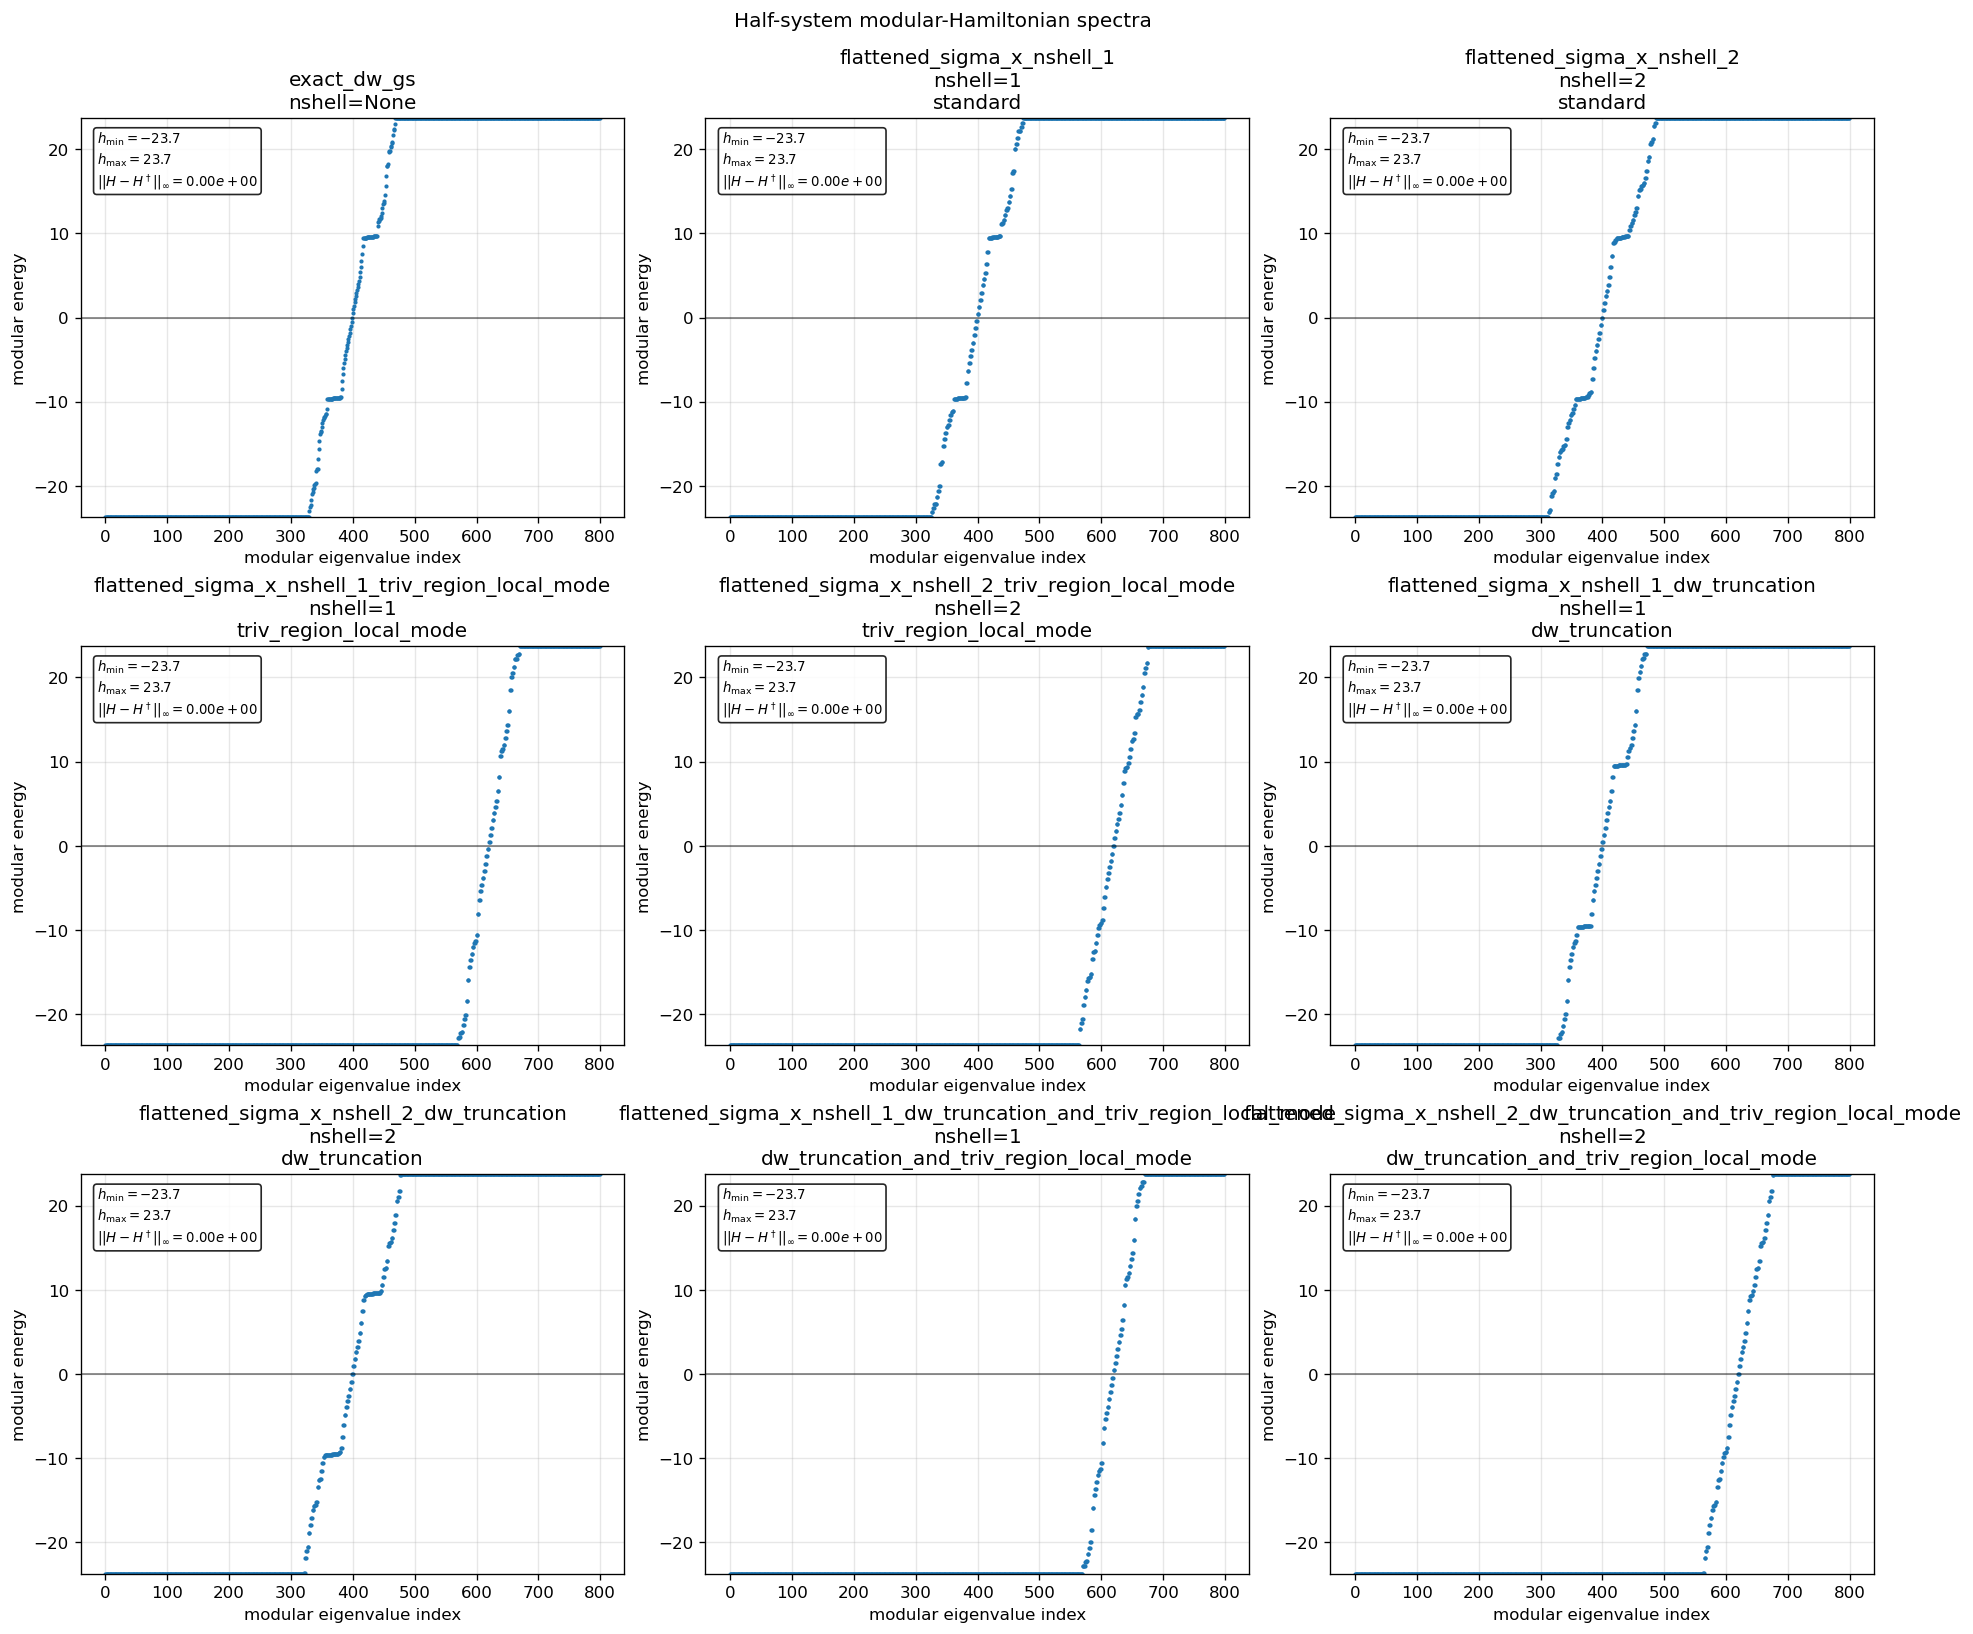

In [25]:

if RUN_FULL_SWEEP:
    run_inputs, dw_loc = build_run_inputs()
    run_inputs = [prepare_modular_data(run) for run in run_inputs]
    modular_spectrum_fig, modular_spectrum_axes, modular_spectrum_summary_df = plot_modular_hamiltonian_spectra(run_inputs)
    injection_configs = build_injection_configs(dw_loc)

    print(f"DW locations: {dw_loc}")
    print(f"Injection configs: {injection_configs}")
    print(f"Number of runs: {len(run_inputs)}")

    records = []
    for run in run_inputs:
        display(Markdown(f"## Hamiltonian: `{run['run_label']}`"))
        print("\n" + "=" * 100)
        print(f"Run: {run['run_label']} | state_type={run['state_type']} | nshell={run['nshell']}")
        print(
            f"  h_mod eig range = [{np.min(run['h_vals']):.6g}, {np.max(run['h_vals']):.6g}] | "
            f"Hermiticity error = {run['hermiticity_error']:.3e}"
        )
        if run["G_A"].shape != (NX * (NY // 2) * 2, NX * (NY // 2) * 2):
            raise ValueError(f"Unexpected reduced shape for {run['run_label']}: {run['G_A'].shape}")

        for config in injection_configs:
            display(Markdown(
                f"### {config['config_name']} | x={config['included_x']} | y={config['included_y_reduced']}"
            ))
            phi0 = injected_phi(config["unit_cells"])
            initial_charge_map = charge_map_from_phi(phi0)
            initial_charge = float(np.sum(initial_charge_map))
            expected_charge = float(2 * len(config["unit_cells"]))
            if not np.isclose(initial_charge, expected_charge, atol=1e-12):
                raise ValueError(
                    f"Initial charge for {config['config_name']} is {initial_charge}, expected {expected_charge}"
                )

            result = evolve_phi_exact_spectral(
                phi0,
                run["h_vals"],
                run["h_vecs"],
                dt=DT_DEFAULT,
                t_final=T_FINAL,
            )

            config_token = safe_token(config["config_name"])
            nshell_token = "none" if run["nshell"] is None else str(run["nshell"])
            origin_dir = OUTPUT_DIR / safe_token(run["run_label"])
            stem = f"{safe_token(MODULAR_COVARIANCE_MODE)}_{safe_token(run['run_label'])}_nshell_{nshell_token}_{config_token}"
            npz_path = origin_dir / f"{stem}.npz"
            video_path = origin_dir / f"{stem}.mp4"

            metadata = {
                "modular_covariance_mode": MODULAR_COVARIANCE_MODE,
                "run_label": run["run_label"],
                "state_type": run["state_type"],
                "nshell": "None" if run["nshell"] is None else str(run["nshell"]),
                "injection_config": config["config_name"],
                "included_x": config["included_x"],
                "included_y_reduced": config["included_y_reduced"],
                "included_y_physical": config["included_y_physical"],
                "n_injected_unit_cells": int(len(config["unit_cells"])),
                "orbitals_per_unit_cell": 2,
                "alpha_1": ALPHA_1,
                "alpha_2": ALPHA_2,
                "Nx": NX,
                "Ny": NY,
                "dw_loc": [int(dw_loc[0]), int(dw_loc[1])],
                "trial_orbital": TRIAL_ORBITAL if run["state_type"] == "flattened_sigma_x" else "exact",
                "configuration_label": run.get("configuration_label", "exact"),
                "dw_truncation": bool(run.get("dw_truncation", False)),
                "triv_region_local_mode": bool(run.get("triv_region_local_mode", False)),
                "dt": result["dt"],
                "n_steps": result["n_steps"],
                "t_final": T_FINAL,
                "h_min": float(np.min(run["h_vals"])),
                "h_max": float(np.max(run["h_vals"])),
                "h_abs_max": float(np.max(np.abs(run["h_vals"]))),
                "h_hermiticity_error": run["hermiticity_error"],
                "initial_charge": result["initial_charge"],
                "final_charge": result["final_charge"],
                "initial_norm": result["initial_norm"],
                "final_norm": result["final_norm"],
                "max_norm_drift": result["max_norm_drift"],
                "max_charge_drift": result["max_charge_drift"],
                "h_vals": run["h_vals"],
            }

            title = (
                f"{run['run_label']} | {config['config_name']} | "
                f"cells={len(config['unit_cells'])} | dt={result['dt']}"
            )

            save_charge_npz(npz_path, result, metadata)
            saved_video_path = save_charge_video(
                video_path,
                result["N_xy"],
                result["times"],
                title=title,
                dw_loc=dw_loc,
                frame_stride=VIDEO_FRAME_STRIDE,
                fps=VIDEO_FPS,
            )
            if DISPLAY_SAVED_VIDEOS:
                display(Video(str(saved_video_path), embed=True))
            if DISPLAY_INTERACTIVE_ANIMATIONS:
                display(charge_animation_jshtml(
                    result["N_xy"],
                    result["times"],
                    title=title,
                    dw_loc=dw_loc,
                    frame_stride=INTERACTIVE_FRAME_STRIDE,
                    fps=VIDEO_FPS,
                ))

            record = {k: v for k, v in metadata.items() if k != "h_vals"}
            record.update({"npz_path": str(npz_path), "video_path": str(saved_video_path)})
            records.append(record)
            print(
                f"  {config['config_name']}: cells={len(config['unit_cells'])}, initial charge={result['initial_charge']:.1f}, "
                f"dt={result['dt']:.5f}, steps={result['n_steps']}, charge drift={result['max_charge_drift']:.3e}, "
                f"norm drift={result['max_norm_drift']:.3e}"
            )

    charge_spreading_summary_df = pd.DataFrame(records)
    save_manifest = save_dataframe_pair(charge_spreading_summary_df, "charge_spreading_summary")
    print(f"Saved {len(charge_spreading_summary_df)} trajectory summaries")
    print(save_manifest)
else:
    print("RUN_FULL_SWEEP=False; not running trajectories.")
    charge_spreading_summary_df = pd.DataFrame()

charge_spreading_summary_df


## Output Manifest

In [26]:

if not charge_spreading_summary_df.empty:
    expected_rows = charge_spreading_summary_df["run_label"].nunique() * charge_spreading_summary_df["injection_config"].nunique()
    actual_videos = sum(Path(p).exists() for p in charge_spreading_summary_df["video_path"])
    actual_npzs = sum(Path(p).exists() for p in charge_spreading_summary_df["npz_path"])
    print(f"summary rows: {len(charge_spreading_summary_df)} / expected {expected_rows}")
    print(f"Video files: {actual_videos} / expected {expected_rows}")
    print(f"NPZ files: {actual_npzs} / expected {expected_rows}")
    print(f"max charge conservation drift: {charge_spreading_summary_df['max_charge_drift'].max():.3e}")
    print(f"max norm conservation drift: {charge_spreading_summary_df['max_norm_drift'].max():.3e}")
else:
    print("No summary rows yet. Run the sweep cell above.")

charge_spreading_summary_df


summary rows: 18 / expected 18
Video files: 18 / expected 18
NPZ files: 18 / expected 18
max charge conservation drift: 4.352e-07
max norm conservation drift: 2.842e-14


,modular_covariance_mode,run_label,state_type,nshell,injection_config,included_x,included_y_reduced,included_y_physical,n_injected_unit_cells,orbitals_per_unit_cell,...,h_abs_max,h_hermiticity_error,initial_charge,final_charge,initial_norm,final_norm,max_norm_drift,max_charge_drift,npz_path,video_path
0,yavg_half_window,exact_dw_gs,exact,None,config1,"[6, 14]","[0, 19]","[0, 19]",4,2,...,23.718998,0.0,8.0,8.0,8.0,8.0,7.105427e-15,1.588576e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
1,yavg_half_window,exact_dw_gs,exact,None,config2,"[5, 6, 7, 13, 14, 15]","[0, 19]","[0, 19]",12,2,...,23.718998,0.0,24.0,24.0,24.0,24.0,2.131628e-14,4.351849e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
2,yavg_half_window,flattened_sigma_x_nshell_1,flattened_sigma_x,1,config1,"[6, 14]","[0, 19]","[0, 19]",4,2,...,23.718998,0.0,8.0,8.0,8.0,8.0,7.993606e-15,1.707099e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
3,yavg_half_window,flattened_sigma_x_nshell_1,flattened_sigma_x,1,config2,"[5, 6, 7, 13, 14, 15]","[0, 19]","[0, 19]",12,2,...,23.718998,0.0,24.0,24.0,24.0,24.0,2.842171e-14,4.232072e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
4,yavg_half_window,flattened_sigma_x_nshell_2,flattened_sigma_x,2,config1,"[6, 14]","[0, 19]","[0, 19]",4,2,...,23.718998,0.0,8.0,8.0,8.0,8.0,9.769963e-15,1.529478e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
5,yavg_half_window,flattened_sigma_x_nshell_2,flattened_sigma_x,2,config2,"[5, 6, 7, 13, 14, 15]","[0, 19]","[0, 19]",12,2,...,23.718998,0.0,24.0,24.0,24.0,24.0,1.776357e-14,4.083737e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
6,yavg_half_window,flattened_sigma_x_nshell_1_triv_region_local_mode,flattened_sigma_x,1,config1,"[6, 14]","[0, 19]","[0, 19]",4,2,...,23.718998,0.0,8.0,8.0,8.0,8.0,1.154632e-14,1.963599e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
7,yavg_half_window,flattened_sigma_x_nshell_1_triv_region_local_mode,flattened_sigma_x,1,config2,"[5, 6, 7, 13, 14, 15]","[0, 19]","[0, 19]",12,2,...,23.718998,0.0,24.0,24.0,24.0,24.0,1.776357e-14,4.165511e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
8,yavg_half_window,flattened_sigma_x_nshell_2_triv_region_local_mode,flattened_sigma_x,2,config1,"[6, 14]","[0, 19]","[0, 19]",4,2,...,23.718998,0.0,8.0,8.0,8.0,8.0,1.243450e-14,1.847611e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
9,yavg_half_window,flattened_sigma_x_nshell_2_triv_region_local_mode,flattened_sigma_x,2,config2,"[5, 6, 7, 13, 14, 15]","[0, 19]","[0, 19]",12,2,...,23.718998,0.0,24.0,24.0,24.0,24.0,2.131628e-14,3.418421e-07,/home/abhuiyan/class_A_fermionic_adaptive_circ...,/home/abhuiyan/class_A_fermionic_adaptive_circ...
